<b>Введение к занятию

<b>Цели занятия</b>


Визуализировать работу механизма self-attention, чтобы понять, как модель «видит» и обрабатывает текст.

Разобраться в различиях архитектур BERT, GPT и T5, а также в том, для каких задач каждая из них подходит лучше всего.

<b>Краткое содержание</b>


Основные техники визуализации внимания (attention).

Особенности архитектур: BERT (Masked Language Modeling), GPT (Autoregressive), T5 (Encoder-Decoder).

Анализ внутренних слоёв моделей с помощью тепловых карт внимания (Attention heatmaps).

Практические примеры, показывающие, как визуализация помогает улучшить понимание работы модели.

<b>Техники визуализации Attention</b>


<b>Attention heatmaps (тепловые карты внимания)</b>

Самая популярная техника. Отображает веса внимания в виде матрицы, где по осям — токены входного и выходного текста.

Яркие участки показывают, на какие слова модель «смотрит» при генерации каждого токена.

    
<b>Graph-based visualization (графовые визуализации)</b>

    
Представляет связи внимания как граф, где узлы — токены, а ребра — веса внимания.

Помогает увидеть, как информация распространяется между словами.


<b>Attention rollout</b>


Техника для агрегирования внимания по всем слоям модели, чтобы понять общую схему «взгляда» модели на вход.

Позволяет получить суммарную карту внимания.



<b>Attention flow tracing (трассировка потока внимания)</b>


Прослеживает путь внимания по слоям и головам, чтобы выявить, как и где именно модель сосредотачивается.

Полезно для изучения особенностей работы разных голов (heads) внимания.


<b>Saliency maps (карты значимости)</b>


Показывают, какие токены наиболее сильно влияют на итоговое предсказание, основанные на градиентах.

Могут дополнять информацию от attention, выявляя важность токенов.

In [1]:
%pip install torch
%pip install transformers
%pip install matplotlib
%pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Attention heatmaps (тепловые карты внимания)
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Инициализация модели и токенизатора
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
def plot_attention_heatmap(layer_idx: int, head_idx: int):
    outputs = model(**inputs)
    attentions = outputs.attentions

    attention = attentions[layer_idx][0][head_idx].detach().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    assert attention.shape[0] == len(tokens), f"mismatch: attention {attention.shape}, tokens {len(tokens)}"

    tokens = tokens[1:-1]
    attention = attention[1:-1, 1:-1]

    plt.figure(figsize=(5, 5))
    ax = sns.heatmap(
        attention,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        square=True,
        cbar=True,
        linewidths=0.5,
        linecolor="gray"
    )

    ax.invert_yaxis()

    plt.title(f"Attention Heatmap (Layer {layer_idx}, Head {head_idx})", fontsize=10)
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

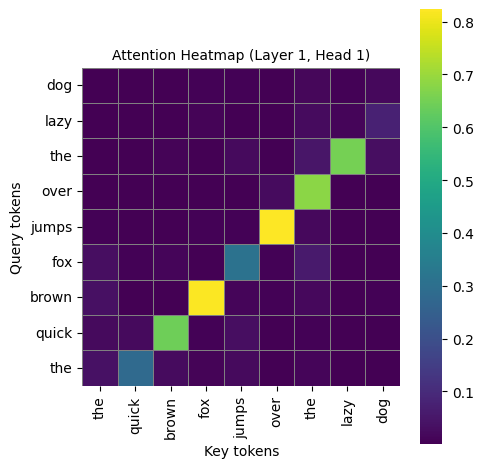

In [5]:
plot_attention_heatmap(1, 1)

In [6]:
#Graph-based visualization (визуализация графа внимания)
import networkx as nx

def plot_attention_graph(layer_idx: int, head_idx: int, threshold: float = 0.1):
    outputs = model(**inputs)
    attentions = outputs.attentions

    attention = attentions[layer_idx][0][head_idx].detach().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    assert attention.shape[0] == len(tokens), f"mismatch: attention {attention.shape}, tokens {len(tokens)}"

    tokens = tokens[1:-1]
    attention = attention[1:-1, 1:-1]

    G = nx.DiGraph()

    for i, token in enumerate(tokens):
        G.add_node(i, label=token)

    for i in range(attention.shape[0]):
        for j in range(attention.shape[1]):
            if attention[i, j] > threshold:
                G.add_edge(i, j, weight=attention[i, j])

    pos = nx.spring_layout(G)
    edge_weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]

    nx.draw(
        G,
        pos,
        with_labels=True,
        labels={i: t for i, t in enumerate(tokens)},
        node_color="lightblue",
        edge_color="orange",
        width=edge_weights,
        arrowsize=15
    )

    plt.title(f"Graph-based Attention Visualization (Layer {layer_idx}, Head {head_idx})")
    plt.show()

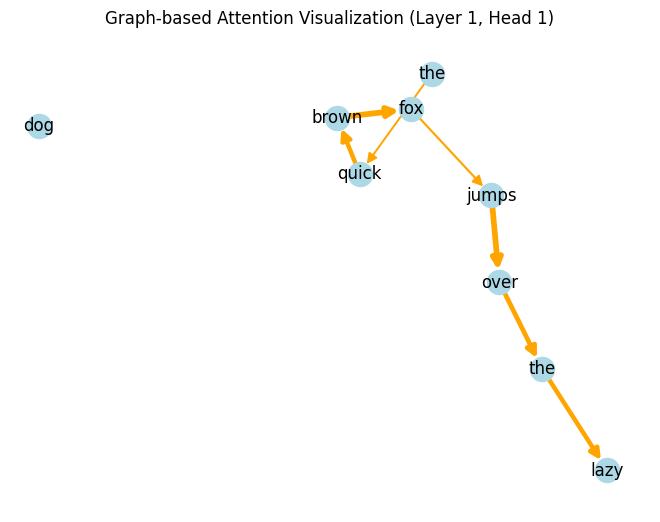

In [7]:
plot_attention_graph(1, 1)

In [8]:
import numpy as np

def compute_attention_rollout(attentions):
    rollout = np.eye(attentions[0].shape[-1])

    for layer_attention in attentions:
        avg_attention = layer_attention[0].mean(axis=0).detach().numpy()

        avg_attention = avg_attention + np.eye(avg_attention.shape[0])
        avg_attention = avg_attention / avg_attention.sum(axis=-1, keepdims=True)

        rollout = rollout @ avg_attention

    return rollout


def plot_attention_rollout():
    outputs = model(**inputs)
    attentions = outputs.attentions

    rollout_map = compute_attention_rollout(attentions)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    tokens = tokens[1:-1]

    rollout_map = rollout_map[1:-1, 1:-1]

    rollout_map_norm = (rollout_map - rollout_map.min()) / (
        rollout_map.max() - rollout_map.min() + 1e-9
    )

    plt.figure(figsize=(len(tokens), len(tokens)))

    ax = sns.heatmap(
        rollout_map_norm,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="magma",
        square=True,
        linewidths=0.3,
        linecolor="gray",
        cbar=True,
    )

    ax.invert_yaxis()

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.title("Attention Rollout (All Layers)")
    plt.xlabel("Query tokens")
    plt.ylabel("Key tokens")
    plt.tight_layout()
    plt.show()

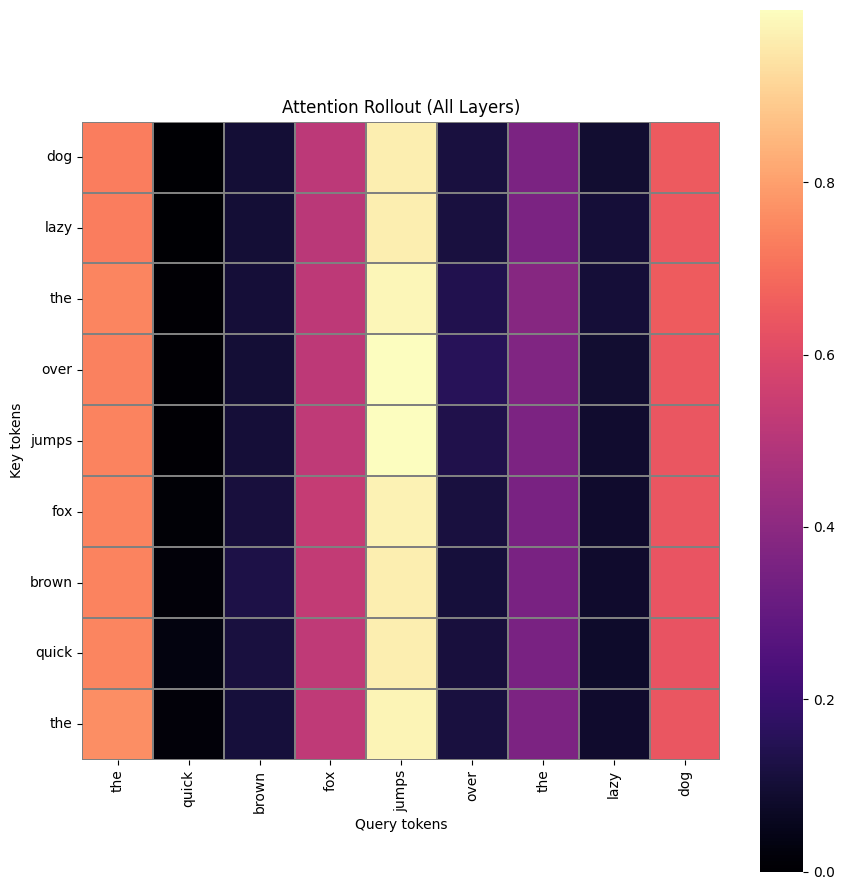

In [9]:
plot_attention_rollout()

In [10]:
#4. Attention flow tracing (простой трассинг внимания по слоям и головам)
# Выведем тепловые карты внимания для всех голов одного слоя

def plot_all_heads(layer_idx: int):
    outputs = model(**inputs)
    attentions = outputs.attentions

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    tokens = tokens[1:-1]

    heads = attentions[layer_idx][0].shape[0]

    fig, axs = plt.subplots(3, 4, figsize=(20, 12))

    for i in range(heads):
        ax = axs[i // 4, i % 4]

        attention = attentions[layer_idx][0][i].detach().numpy()
        attention = attention[1:-1, 1:-1]

        sns.heatmap(
            attention,
            xticklabels=tokens,
            yticklabels=tokens,
            ax=ax,
            cmap="coolwarm"
        )

        ax.set_title(f"Layer {layer_idx+1} Head {i+1}")
        ax.tick_params(axis="x", rotation=90)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()

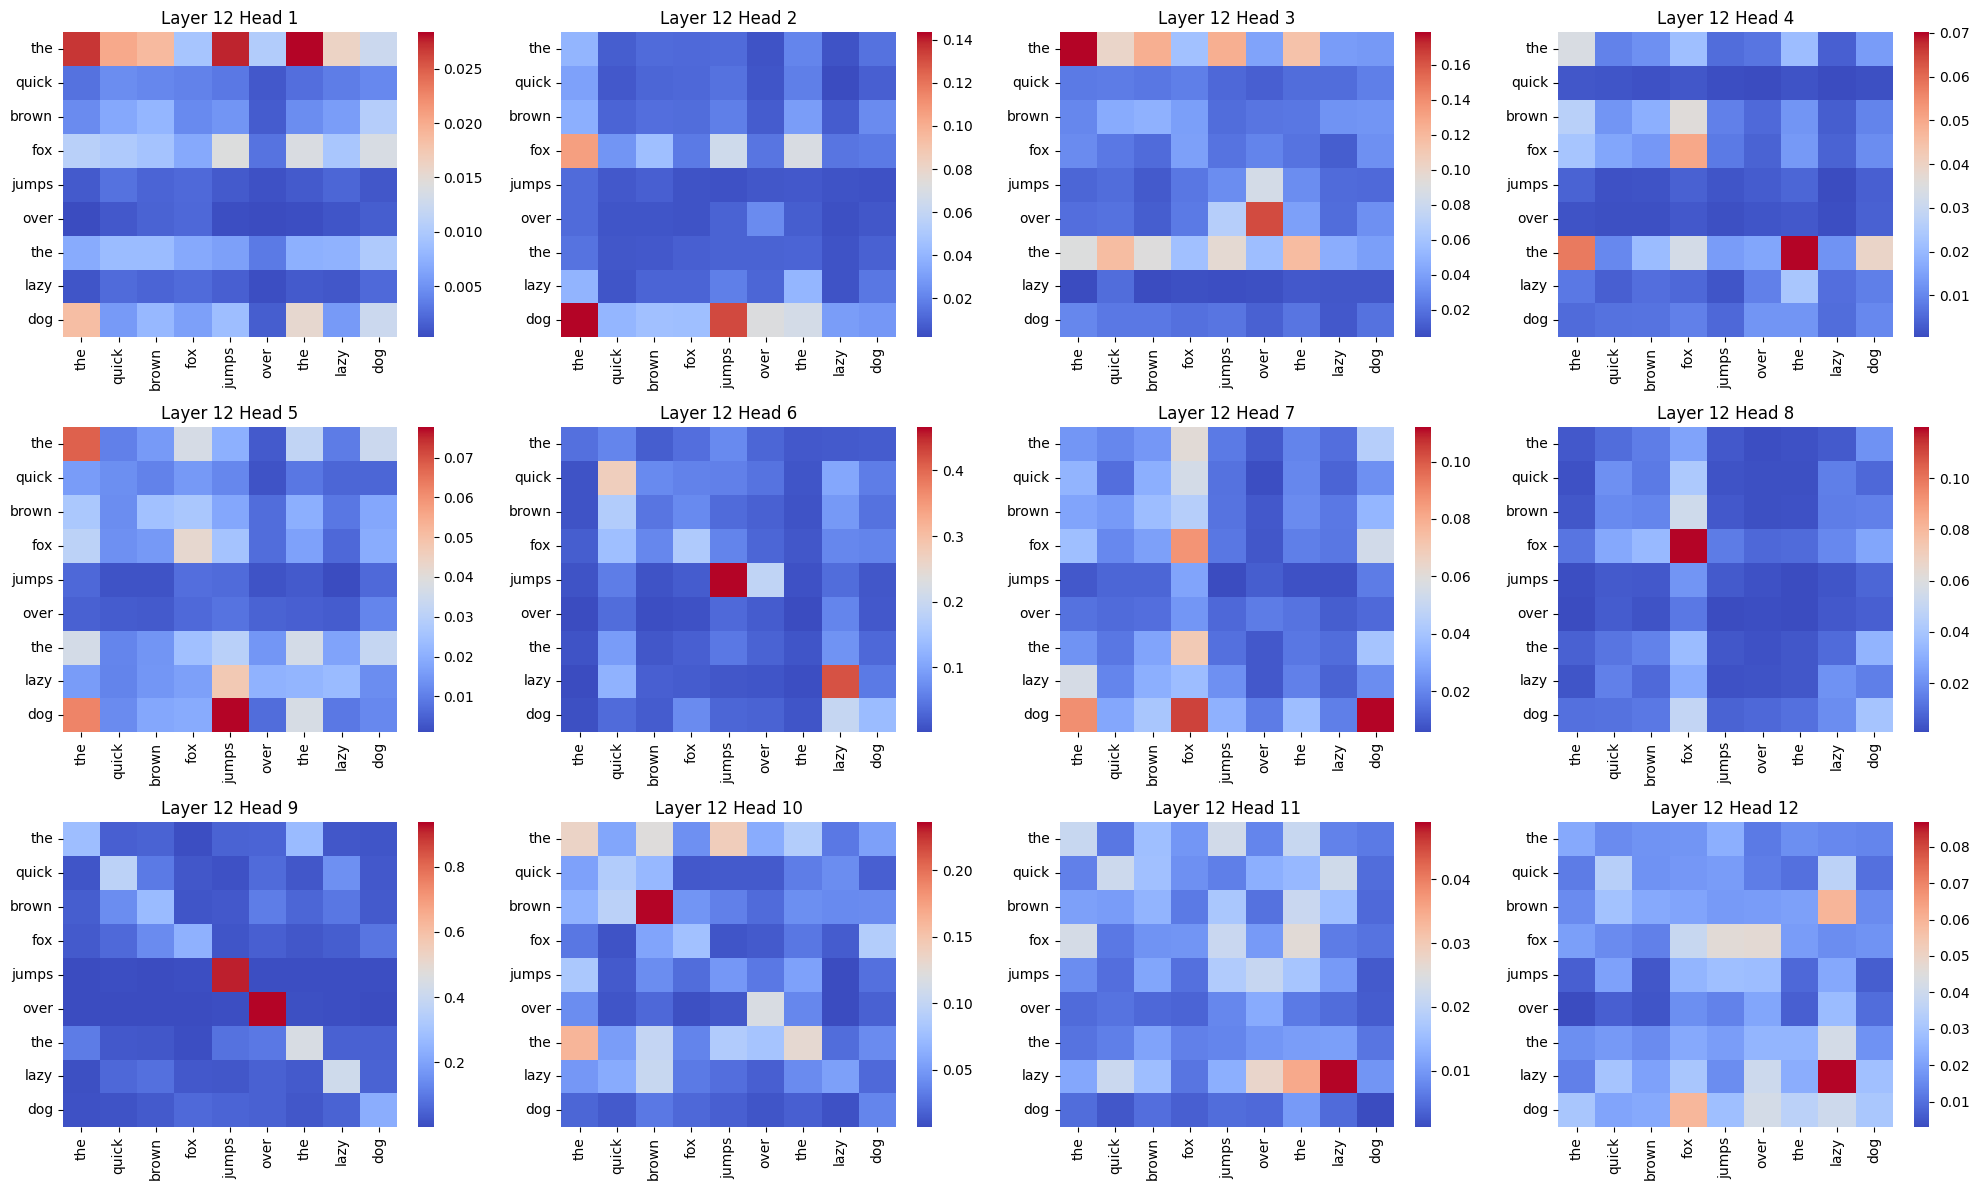

In [11]:
plot_all_heads(11)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


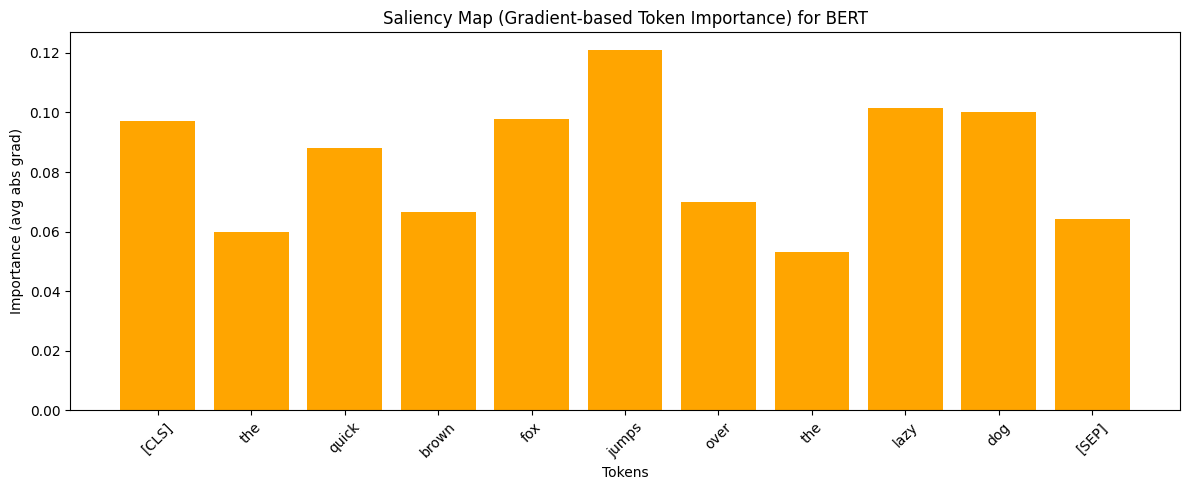

In [12]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Инициализация токенизатора и модели (BERT base)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

# Текст для анализа
text = "The quick brown fox jumps over the lazy dog"

# Токенизация
inputs = tokenizer(text, return_tensors='pt')
input_ids = inputs['input_ids']

# Получаем слой эмбеддингов модели
embedding_layer = model.get_input_embeddings()

# Получаем эмбеддинги входных токенов
embeddings = embedding_layer(input_ids)
embeddings.requires_grad_()     # Включаем подсчет градиентов
embeddings.retain_grad()        # Сохраняем градиенты для не-листового тензора

# Прямой проход по модели с входными эмбеддингами
outputs = model(inputs_embeds=embeddings)

# Используем сумму по последнему слою CLS-токена (первый токен)
cls_token_embedding = outputs.last_hidden_state[:, 0, :]
score = cls_token_embedding.sum()
score.backward()  # Обратное распространение ошибки

# Получаем градиенты по эмбеддингам
grads = embeddings.grad.abs().squeeze(0)  # shape (seq_len, embedding_dim)

# Усредняем по размерности эмбеддинга, чтобы получить значение значимости для каждого токена
token_importance = grads.mean(dim=1).detach().cpu().numpy()

# Получаем токены для отображения
tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())

# Визуализация
plt.figure(figsize=(12, 5))
plt.bar(range(len(tokens)), token_importance, color='orange')
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.xlabel("Tokens")
plt.ylabel("Importance (avg abs grad)")
plt.title("Saliency Map (Gradient-based Token Importance) for BERT")
plt.tight_layout()
plt.show()
